# Brent Oil Price Analysis: Task 1 - Foundation & EDA
**Business Context:** Analysis for Birhan Energies to understand the impact of geopolitical and economic events on Brent oil prices (1987-2022).  
**Objectives:** * Outline the data analysis workflow and state analytical assumptions/limitations.
* Compile a research-backed dataset of 15 key global events.
* Analyze time series properties (trend, stationarity via ADF test, and volatility clustering).
* Prepare the data foundation for Bayesian Change Point detection.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import os

os.makedirs('../reports/figures', exist_ok=True)

ROOT_DIR = os.getcwd()

DATA_DIR_RAW = os.path.join(ROOT_DIR, 'data','BrentOilPrices.csv')
EVENT_DATA_DIR = os.path.join(ROOT_DIR, 'data', 'Events.csv')


plt.style.use('ggplot')
%matplotlib inline

In [13]:
df = pd.read_csv(DATA_DIR_RAW)

# Handle the specific '20-May-87' format
# Use 'mixed' to handle both '20-May-87' and 'Apr 22, 2020'
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Ensure everything is sorted chronologically
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB
None

First 5 rows:
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


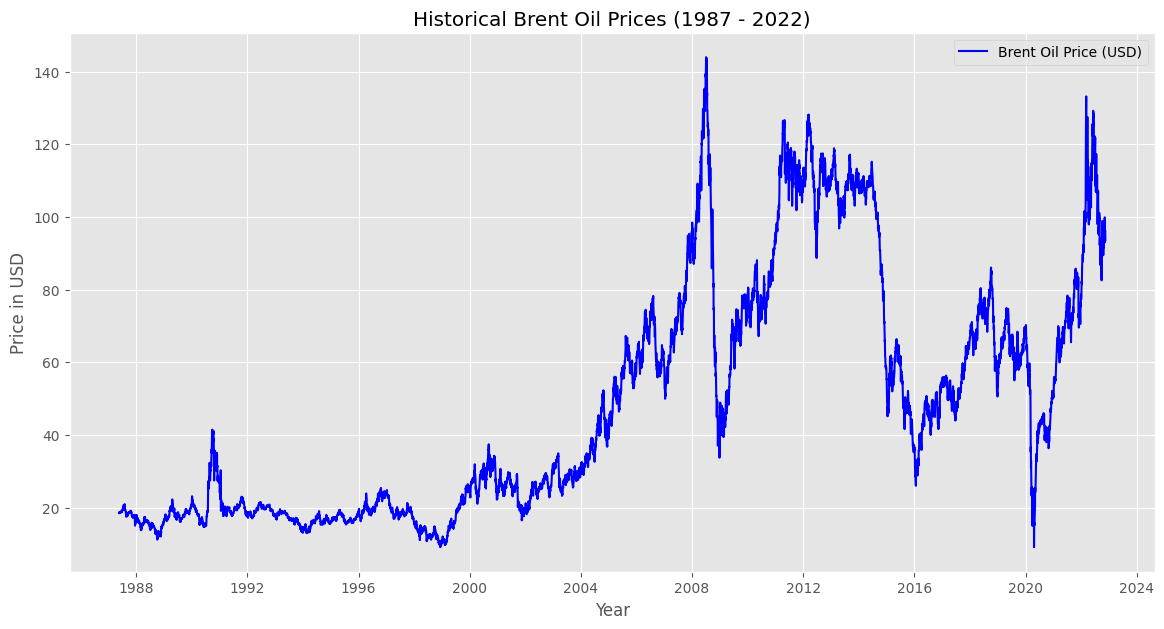

Price Range: $9.1 to $143.95


In [14]:
# Task 1 - Trend Analysis (Plotting Raw Prices)
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Price'], label='Brent Oil Price (USD)', color='blue')
plt.title('Historical Brent Oil Prices (1987 - 2022)')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()

# Save for report
plt.savefig('../reports/figures/01_price_trend.png')
plt.show()

# Quick summary
print(f"Price Range: ${df['Price'].min()} to ${df['Price'].max()}")

In [15]:
# Research & Compile Event Data
# This creates your events.csv file directly from the notebook
events_data = {
    'Date': [
        '1990-08-02', '1997-07-01', '2001-09-11', '2003-03-20', '2008-07-11', 
        '2011-02-15', '2014-11-27', '2016-11-30', '2018-05-08', '2020-01-30', 
        '2020-03-08', '2021-06-01', '2022-02-24', '2022-03-08', '2022-06-01'
    ],
    'Event': [
        'Gulf War Invasion', 'Asian Financial Crisis', '9/11 Terrorist Attacks', 
        'Iraq War Invasion', '2008 Financial Peak', 'Arab Spring / Libya Crisis', 
        'OPEC No-Cut Decision', 'OPEC Algiers Accord', 'US Exit from Iran Deal', 
        'WHO Declares COVID Emergency', 'Russia-Saudi Price War', 'Post-COVID Demand Surge', 
        'Russian Invasion of Ukraine', 'US Ban on Russian Oil', 'OPEC+ Large Output Hike'
    ]
}

df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

df_events.to_csv(EVENT_DATA_DIR, index=False)

### Assumptions and Limitations

### Assumptions:
* **Structural Homogeneity:** We assume that between change points, the oil price follows a stable mean and variance.
* **Data Integrity:** We assume the daily closing prices reflect the true global equilibrium at that time.

### Limitations & The Causality Problem:
* **Correlation vs. Causation:** Our Bayesian model identifies **statistical structural breaks** (dates where the price behavior changed). However, a change point occurring near an event (e.g., the 2022 Invasion) suggests a **correlation**, not a mathematical proof of **causality**. 
* **Overlapping Factors:** Often, multiple events happen at once (e.g., COVID-19 demand drops + a Russia/Saudi supply war). The model can detect the "break" but cannot perfectly separate how much of the price drop was "COVID" vs. "Supply War."